# FRA Project (FRA)

## Part 1 - Credit Risk

## Problem Statement

### Businesses or companies can fall prey to default if they are not able to keep up their debt obligations. Defaults will lead to a lower credit rating for the company which in turn reduces its chances of getting credit in the future and may have to pay higher interests on existing debts as well as any new obligations. From an investor's point of view, he would want to invest in a company if it is capable of handling its financial obligations, can grow quickly, and is able to manage the growth scale.
### A balance sheet is a financial statement of a company that provides a snapshot of what a company owns, owes, and the amount invested by the shareholders. Thus, it is an important tool that helps evaluate the performance of a business.
### Data that is available includes information from the financial statement of the companies for the previous year (2015). Also, information about the Networth of the company in the following year (2016) is provided which can be used to drive the labeled field.
### Explanation of data fields available in Data Dictionary, 'Credit Default Data Dictionary.xlsx'

### Hints :
### Dependent variable - We need to create a default variable which should take the value of 1 when net worth next year is negative & 0 when net worth is positive.
### Test Train Split -   Split the data into the Train and Test dataset in a ratio of 67:33 and use random_state =42. Model Building is to be done on Train Dataset and Model Validation is to be done on Test Dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, accuracy_score

In [2]:
df1 = pd.read_excel("Company_Data2015-2.xlsx")

### Basic EDA

In [3]:
df1.head()

,Co_Code,Co_Name,Networth Next Year,Equity Paid Up,Networth,Capital Employed,Total Debt,Gross Block,Net Working Capital,Current Assets,...,PBIDTM (%)[Latest],PBITM (%)[Latest],PBDTM (%)[Latest],CPM (%)[Latest],APATM (%)[Latest],Debtors Velocity (Days),Creditors Velocity (Days),Inventory Velocity (Days),Value of Output/Total Assets,Value of Output/Gross Block
0,16974,Hind.Cables,-8021.60,419.36,-7027.48,-1007.24,5936.03,474.30,-1076.34,40.50,...,0.00,0.00,0.00,0.00,0.00,0,0,45.0,0.00,0.00
1,21214,Tata Tele. Mah.,-3986.19,1954.93,-2968.08,4458.20,7410.18,9070.86,-1098.88,486.86,...,-10.30,-39.74,-57.74,-57.74,-87.18,29,101,2.0,0.31,0.24
2,14852,ABG Shipyard,-3192.58,53.84,506.86,7714.68,6944.54,1281.54,4496.25,9097.64,...,-5279.14,-5516.98,-7780.25,-7723.67,-7961.51,97,558,0.0,-0.03,-0.26
3,2439,GTL,-3054.51,157.30,-623.49,2353.88,2326.05,1033.69,-2612.42,1034.12,...,-3.33,-7.21,-48.13,-47.70,-51.58,93,63,2.0,0.24,1.90
4,23505,Bharati Defence,-2967.36,50.30,-1070.83,4675.33,5740.90,1084.20,1836.23,4685.81,...,-295.55,-400.55,-845.88,379.79,274.79,3887,346,0.0,0.01,0.05


In [4]:
df1.shape

(3586, 67)

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3586 entries, 0 to 3585
Data columns (total 67 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Co_Code                              3586 non-null   int64  
 1   Co_Name                              3586 non-null   object 
 2   Networth Next Year                   3586 non-null   float64
 3   Equity Paid Up                       3586 non-null   float64
 4   Networth                             3586 non-null   float64
 5   Capital Employed                     3586 non-null   float64
 6   Total Debt                           3586 non-null   float64
 7   Gross Block                          3586 non-null   float64
 8   Net Working Capital                  3586 non-null   float64
 9   Current Assets                       3586 non-null   float64
 10  Current Liabilities and Provisions   3586 non-null   float64
 11  Total Assets/Liabilities      

In [6]:
df1.describe(include="all")

,Co_Code,Co_Name,Networth Next Year,Equity Paid Up,Networth,Capital Employed,Total Debt,Gross Block,Net Working Capital,Current Assets,...,PBIDTM (%)[Latest],PBITM (%)[Latest],PBDTM (%)[Latest],CPM (%)[Latest],APATM (%)[Latest],Debtors Velocity (Days),Creditors Velocity (Days),Inventory Velocity (Days),Value of Output/Total Assets,Value of Output/Gross Block
count,3586.000000,3586,3586.000000,3586.000000,3586.000000,3586.000000,3586.000000,3586.000000,3586.000000,3586.000000,...,3585.000000,3585.000000,3585.000000,3585.000000,3585.000000,3586.000000,3.586000e+03,3483.000000,3586.000000,3586.000000
unique,NaN,3586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Progress. Extr.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,16065.388734,NaN,725.045251,62.966584,649.746299,2799.611054,1994.823779,594.178829,410.809665,1960.349172,...,-51.162890,-109.213414,-311.570357,-307.005632,-365.056187,603.894032,2.057855e+03,79.644559,0.819757,61.884548
std,19776.817379,NaN,4769.681004,778.761744,4091.988792,26975.135385,23652.842746,4871.547802,6301.218546,22577.570829,...,1795.131025,3057.635870,10921.592639,10676.149629,12500.051387,10636.759580,5.416948e+04,137.847792,1.201400,976.824352
min,4.000000,NaN,-8021.600000,0.000000,-7027.480000,-1824.750000,-0.720000,-41.190000,-13162.420000,-0.910000,...,-78870.450000,-141600.000000,-590500.000000,-572000.000000,-688600.000000,0.000000,0.000000e+00,-199.000000,-0.330000,-61.000000
25%,3029.250000,NaN,3.985000,3.750000,3.892500,7.602500,0.030000,0.570000,0.942500,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,8.000000e+00,0.000000,0.070000,0.270000
50%,6077.500000,NaN,19.015000,8.290000,18.580000,39.090000,7.490000,15.870000,10.145000,24.540000,...,8.070000,5.230000,4.690000,3.890000,1.590000,49.000000,3.900000e+01,35.000000,0.480000,1.530000
75%,24269.500000,NaN,123.802500,19.517500,117.297500,226.605000,72.350000,131.895000,61.175000,135.277500,...,18.990000,14.290000,14.110000,11.390000,7.410000,106.000000,8.900000e+01,96.000000,1.160000,4.910000


In [7]:
df1.duplicated().sum()

0

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
        52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66]),
 <a list of 66 Text major ticklabel objects>)

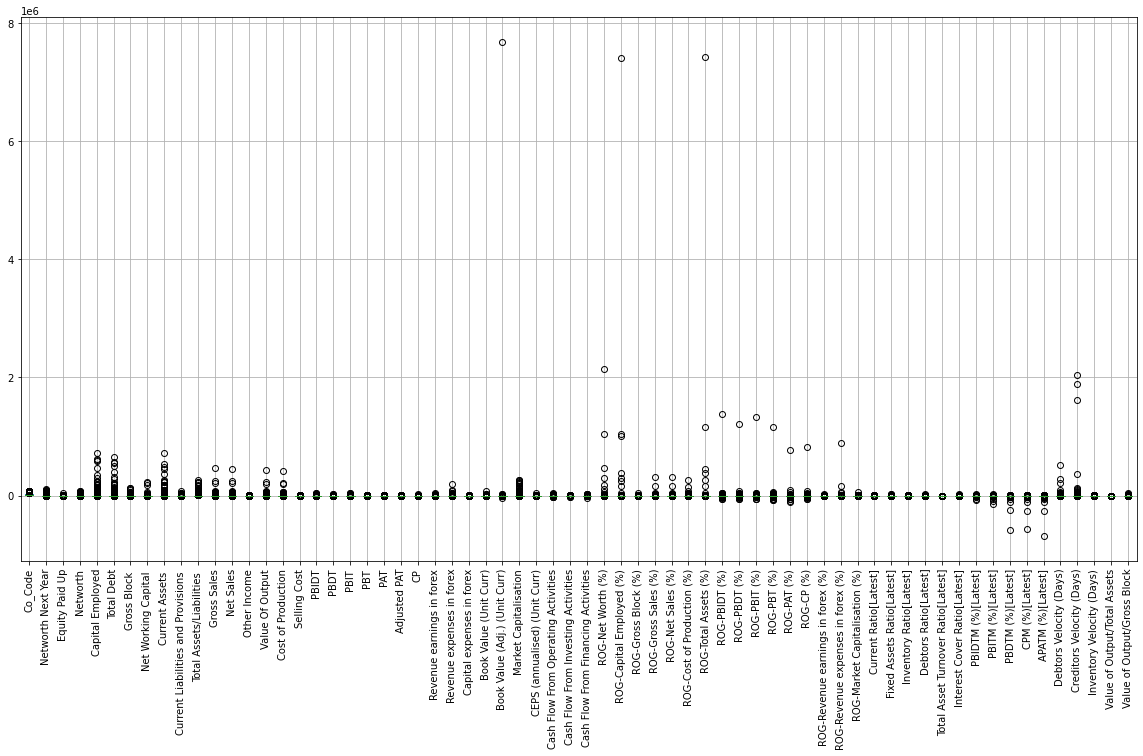

In [8]:
df1.boxplot(figsize=(20,10))
plt.xticks(rotation=90)

### Outlier Treatment

In [9]:
def check_outlier(col):
    sorted(col)
    Q1,Q3=col.quantile([.25,.75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

#### Checking lower and upper whiskers

In [10]:
check_outlier(df1['Networth Next Year'])

(-175.74125, 303.52875000000006)

In [11]:
check_outlier(df1['Net Working Capital '])

(-89.40625, 151.52375)

#### Capping the outlier

In [12]:
df1_copy = df1.copy()

In [13]:
# Dropping records higher than upper whisker
df1_copy.drop(df1_copy[df1_copy['Networth Next Year']>296.8].index, inplace=True)
df1_copy.drop(df1_copy[df1_copy['Net Working Capital '] >151.3].index, inplace=True)

# Capping values lower than lower whisker
df1_copy['Networth Next Year'] = np.where(df1_copy['Networth Next Year'] <-171.8, -171.8,df1_copy['Networth Next Year'])
df1_copy['Net Working Capital '] = np.where(df1_copy['Net Working Capital '] <-89.2, -89.2,df1_copy['Net Working Capital '])


In [14]:
df1_copy.shape

(2839, 67)

#### Lets visualize these variables

#### Net Working Capital v/s Default variable - before outlier treatment

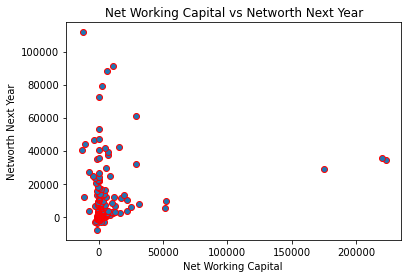

In [15]:
plt.scatter(df1['Net Working Capital '], df1['Networth Next Year'], edgecolors='r')
plt.xlabel('Net Working Capital ')
plt.ylabel('Networth Next Year')
plt.title('Net Working Capital vs Networth Next Year')
plt.show()

#### Net Working Capital v/s Default variable - after outlier treatment

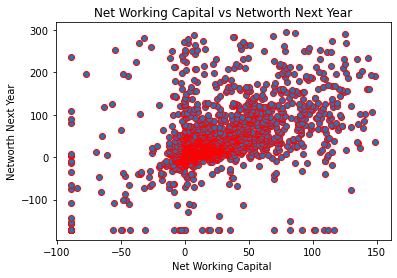

In [16]:
plt.scatter(df1_copy['Net Working Capital '], df1_copy['Networth Next Year'], edgecolors='r')
plt.xlabel('Net Working Capital ')
plt.ylabel('Networth Next Year')
plt.title('Net Working Capital vs Networth Next Year')
plt.show()

### Missing Value Treatment	

In [17]:
df1.isnull().sum().sum()

118

In [18]:
df1.dropna(inplace=True)

In [19]:
df1.isna().sum().sum()

0

### Transform target variable into 0 and 1	

In [20]:
default = []

for i in df1['Networth Next Year']:

    if i>=0:
        default.append(0)
    if i<0:
        default.append(1)


In [21]:
df1['default'] = default

In [22]:
df1.default

0       1
1       1
2       1
3       1
4       1
       ..
3580    0
3582    0
3583    0
3584    0
3585    0
Name: default, Length: 3478, dtype: int64

### Perform Univariate & bivariate analysis(including Heatmap)

#### Checking Minimum

In [23]:
df1.min()

Co_Code                                  4
Co_Name                         20 Microns
Networth Next Year                 -8021.6
Equity Paid Up                           0
Networth                          -7027.48
                                   ...    
Creditors Velocity (Days)                0
Inventory Velocity (Days)             -199
Value of Output/Total Assets         -0.33
Value of Output/Gross Block            -61
default                                  0
Length: 68, dtype: object

#### Checking Maximum

In [24]:
df1.max()

Co_Code                                   72493
Co_Name                         iStreet Network
Networth Next Year                       111729
Equity Paid Up                          42263.5
Networth                                81657.4
                                     ...       
Creditors Velocity (Days)               2034145
Inventory Velocity (Days)                   996
Value of Output/Total Assets              17.63
Value of Output/Gross Block               43404
default                                       1
Length: 68, dtype: object

#### Checking IQR

In [25]:
df1.quantile(0.75) - df1.quantile(0.25)

Co_Code                         21265.2500
Networth Next Year                117.1775
Equity Paid Up                     15.5000
Networth                          110.1825
Capital Employed                  215.4175
                                   ...    
Creditors Velocity (Days)          82.0000
Inventory Velocity (Days)          96.0000
Value of Output/Total Assets        1.1000
Value of Output/Gross Block         4.5775
default                             0.0000
Length: 67, dtype: float64

#### Checking Variance

In [26]:
df1.var()

Co_Code                         3.915885e+08
Networth Next Year              2.107882e+07
Equity Paid Up                  6.249622e+05
Networth                        1.555522e+07
Capital Employed                5.896179e+08
                                    ...     
Creditors Velocity (Days)       3.023405e+09
Inventory Velocity (Days)       1.901089e+04
Value of Output/Total Assets    1.420950e+00
Value of Output/Gross Block     9.833967e+05
default                         9.644848e-02
Length: 67, dtype: float64

#### Checking skew

In [27]:
df1.skew()

Co_Code                          1.605670
Networth Next Year              13.550960
Equity Paid Up                  45.267894
Networth                        12.043955
Capital Employed                19.551332
                                  ...    
Creditors Velocity (Days)       33.635067
Inventory Velocity (Days)        3.496236
Value of Output/Total Assets     4.699987
Value of Output/Gross Block     31.529906
default                          2.525215
Length: 67, dtype: float64

#### Checking Histogram

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000002843BE3400>,
      dtype=object)

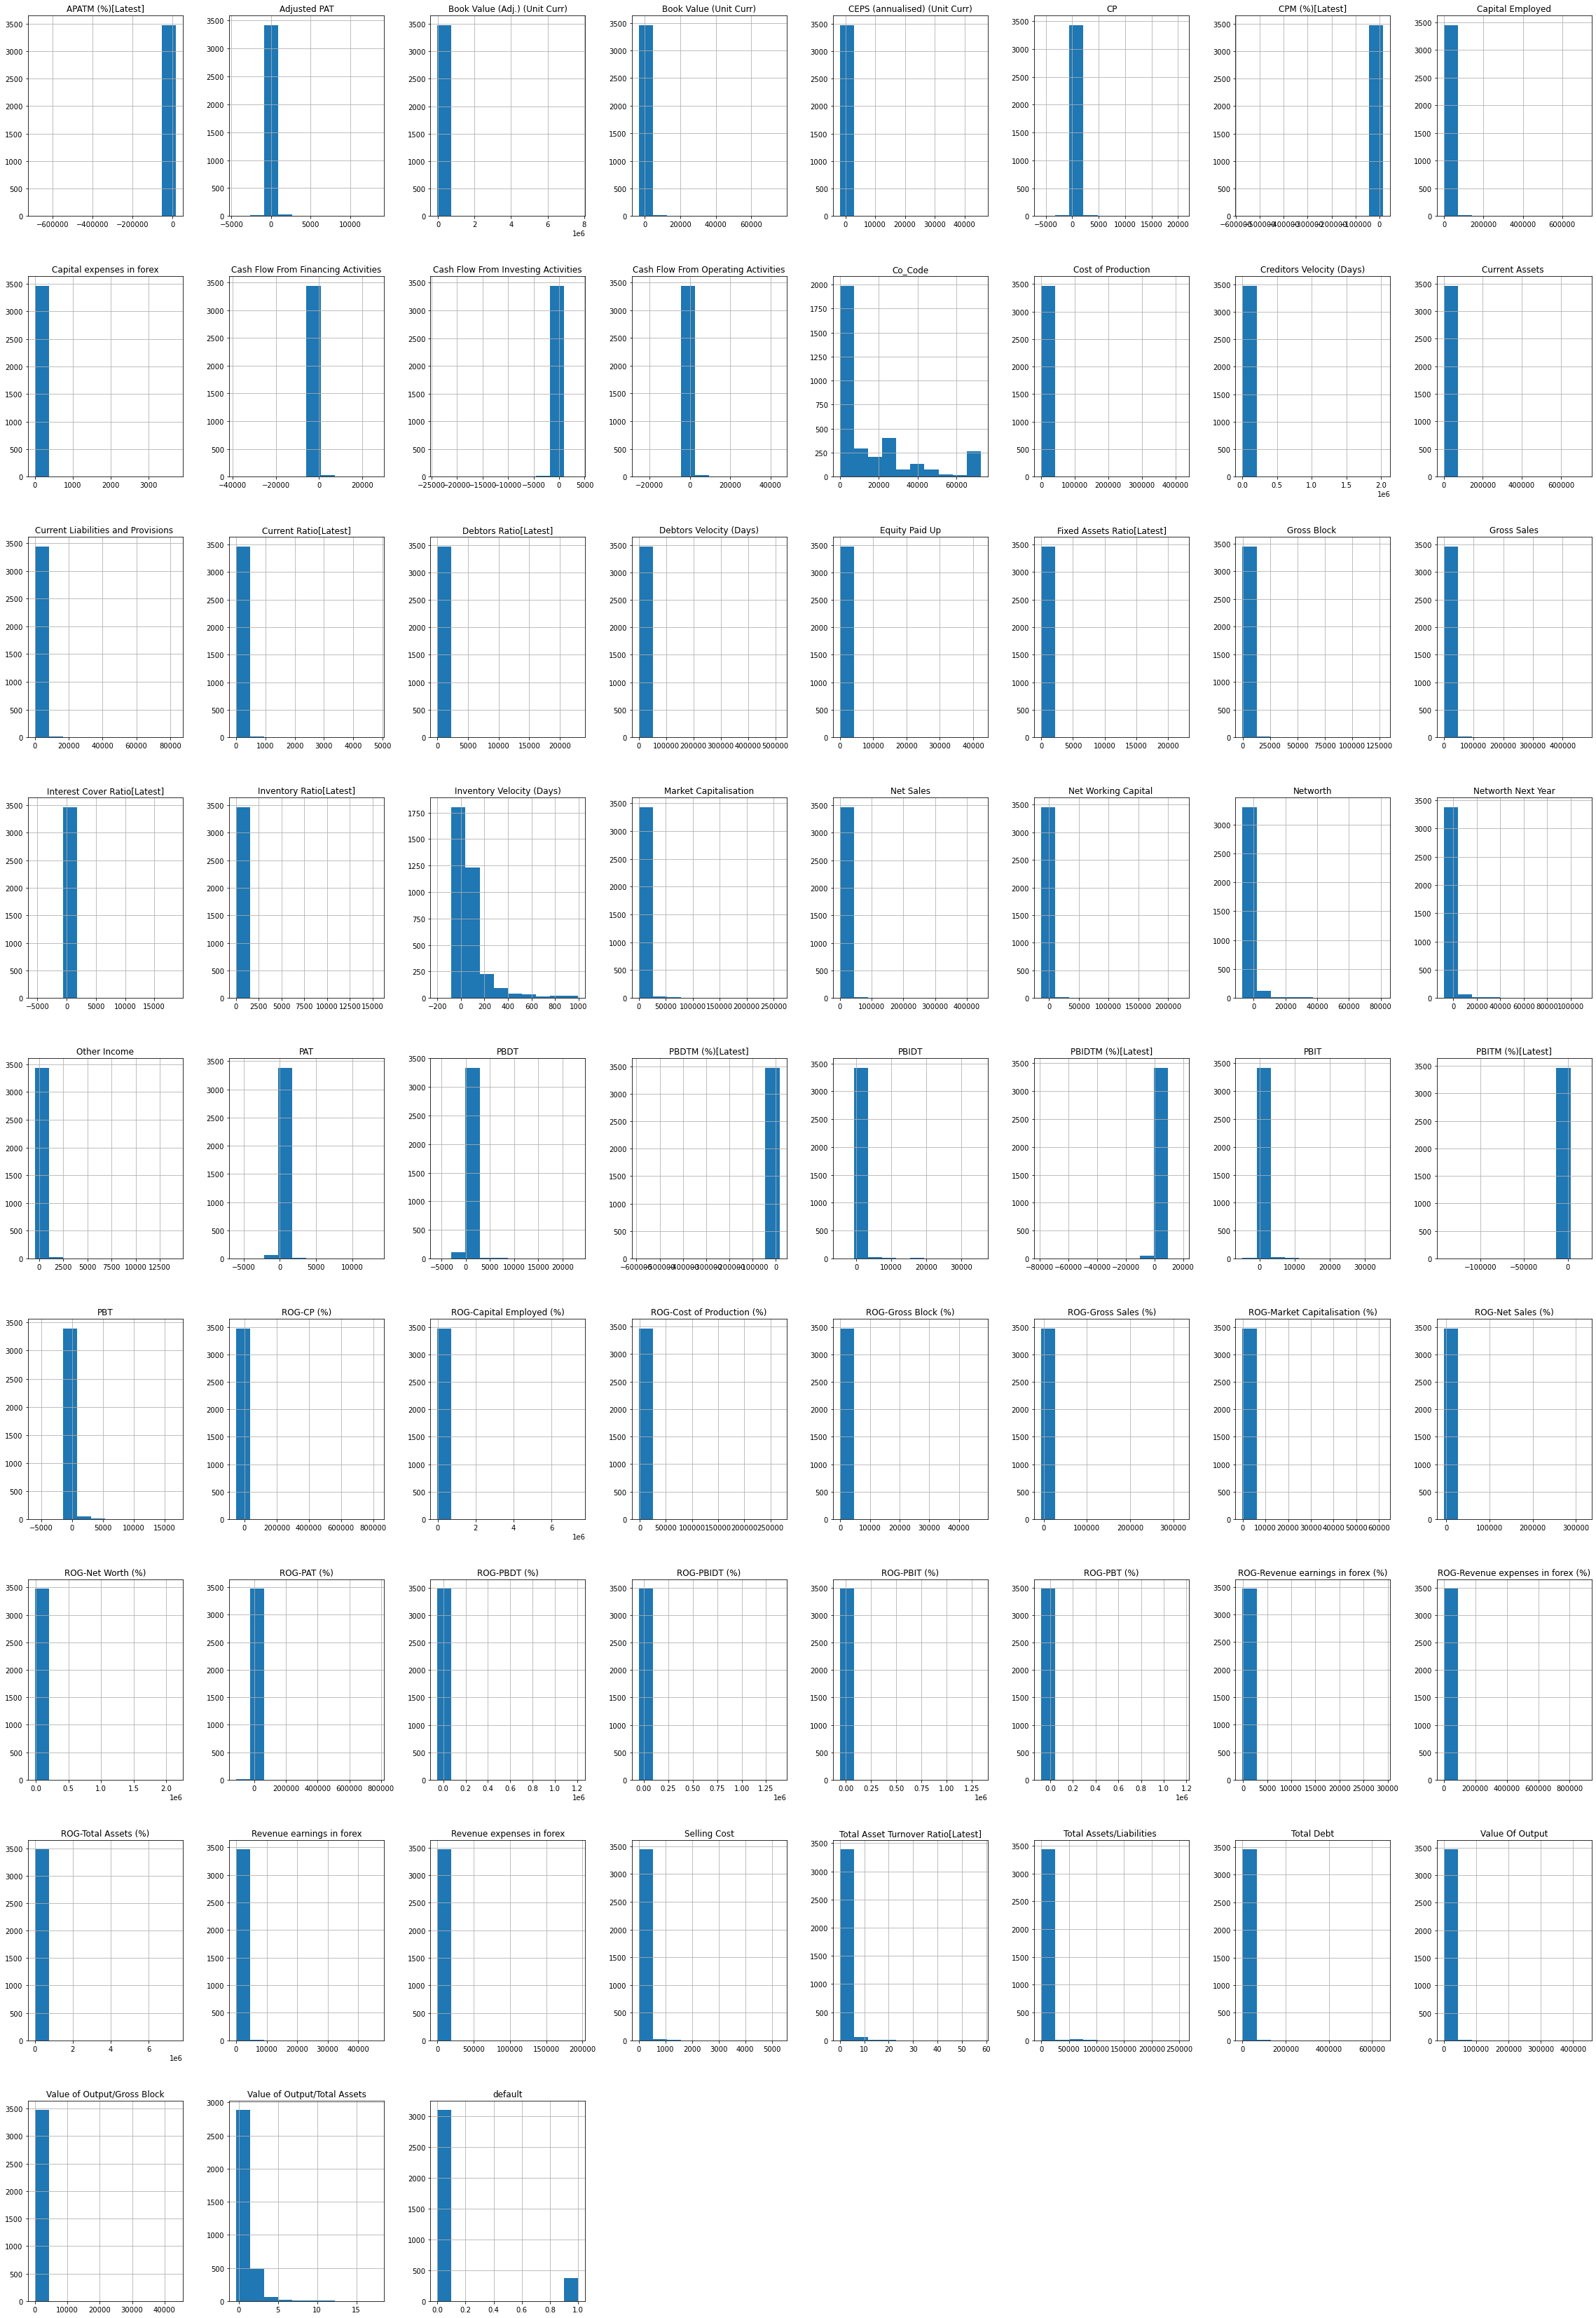

In [28]:
df1.hist(figsize=(40,60))

#### Checking Boxplot

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
        52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67]),
 <a list of 67 Text major ticklabel objects>)

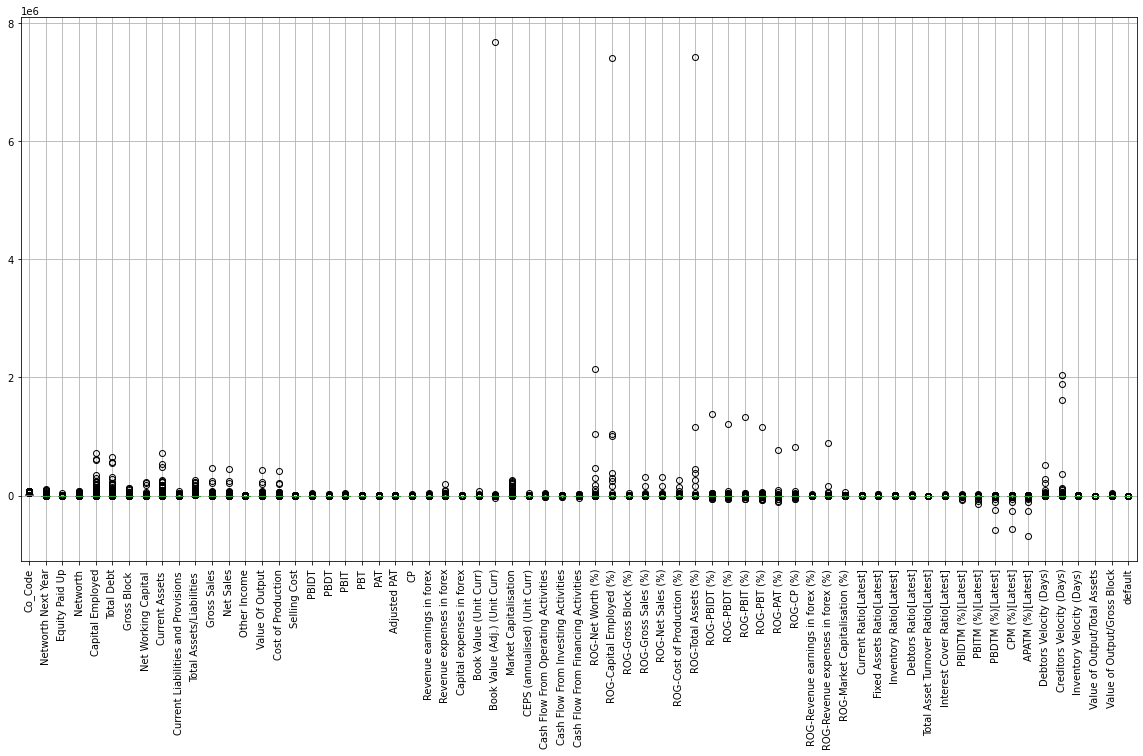

In [29]:
df1.boxplot(figsize=(20,10))
plt.xticks(rotation=90)

#### Checking Pairplot

In [ ]:
sns.pairplot(df1)

#### Checking Covariance

In [30]:
df1.cov()

,Co_Code,Networth Next Year,Equity Paid Up,Networth,Capital Employed,Total Debt,Gross Block,Net Working Capital,Current Assets,Current Liabilities and Provisions,...,PBITM (%)[Latest],PBDTM (%)[Latest],CPM (%)[Latest],APATM (%)[Latest],Debtors Velocity (Days),Creditors Velocity (Days),Inventory Velocity (Days),Value of Output/Total Assets,Value of Output/Gross Block,default
Co_Code,3.915885e+08,-4.671246e+06,-9.233402e+04,-4.358660e+06,-1.970515e+07,-1.489198e+07,-4.244065e+06,-2.423136e+06,-1.489444e+07,-2.906043e+06,...,-431049.266815,-1.829471e+06,-1.765467e+06,-2.232579e+06,-6.281159e+05,-2.061198e+07,-152164.382558,2911.970209,724392.078940,-832.290309
Networth Next Year,-4.671246e+06,2.107882e+07,1.377321e+06,1.753496e+07,5.952982e+07,3.952144e+07,1.749481e+07,7.393630e+06,3.884718e+07,9.324233e+06,...,89693.215924,9.807133e+04,8.553837e+04,1.318777e+05,-3.301810e+05,-1.355902e+06,-16438.689617,-118.200492,-29719.158802,-94.265155
Equity Paid Up,-9.233402e+04,1.377321e+06,6.249622e+05,1.264245e+06,2.800660e+06,1.373799e+06,1.063441e+06,2.411106e+05,1.061676e+06,3.656494e+05,...,6302.148852,2.684107e+03,2.294810e+03,1.841169e+03,2.398602e+03,-8.932001e+04,-1930.674783,-25.742930,-1751.110682,-3.623380
Networth,-4.358660e+06,1.753496e+07,1.264245e+06,1.555522e+07,5.566247e+07,3.780702e+07,1.490722e+07,6.840536e+06,3.714411e+07,8.300900e+06,...,60297.196885,7.860029e+03,-3.778364e+03,3.286462e+04,-2.714163e+05,-1.199834e+06,-11148.373757,-126.894558,-26985.936939,-79.997286
Capital Employed,-1.970515e+07,5.952982e+07,2.800660e+06,5.566247e+07,5.896179e+08,5.125518e+08,3.358225e+07,4.273804e+07,4.904841e+08,3.903414e+07,...,227804.383152,3.452858e+05,3.229979e+05,4.518692e+05,-1.352432e+06,-5.121822e+06,-119378.776626,-425.372499,-103873.032934,-255.738337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Creditors Velocity (Days),-2.061198e+07,-1.355902e+06,-8.932001e+04,-1.199834e+06,-5.121822e+06,-3.632297e+06,-1.198951e+06,-7.843387e+05,-3.199722e+06,-3.755911e+05,...,7533.241155,-9.467795e+05,-9.729900e+05,-9.042135e+05,1.497447e+08,3.023405e+09,-146542.257264,-1580.084057,-125116.219828,421.983848
Inventory Velocity (Days),-1.521644e+05,-1.643869e+04,-1.930675e+03,-1.114837e+04,-1.193788e+05,-1.026043e+05,1.118361e+03,-9.679139e+03,-8.806031e+04,-6.086800e+02,...,-461.236396,5.353606e+03,5.208278e+03,6.113505e+03,3.263473e+03,-1.465423e+05,19010.888312,-10.888255,-220.291488,1.085496
Value of Output/Total Assets,2.911970e+03,-1.182005e+02,-2.574293e+01,-1.268946e+02,-4.253725e+02,-2.668010e+02,-5.635773e+01,-1.994502e+02,-2.084447e+02,-3.412007e+00,...,94.064059,2.641985e+02,2.589166e+02,3.054637e+02,-4.376736e+02,-1.580084e+03,-10.888255,1.420950,171.493614,-0.037773
Value of Output/Gross Block,7.243921e+05,-2.971916e+04,-1.751111e+03,-2.698594e+04,-1.038730e+05,-7.315686e+04,-3.671948e+04,5.851478e+03,-6.420762e+04,-1.701354e+04,...,7653.756598,1.987332e+04,1.945035e+04,2.313477e+04,-3.587896e+04,-1.251162e+05,-220.291488,171.493614,983396.663271,-6.325756


#### Checking Correlation

In [31]:
df1.corr()

,Co_Code,Networth Next Year,Equity Paid Up,Networth,Capital Employed,Total Debt,Gross Block,Net Working Capital,Current Assets,Current Liabilities and Provisions,...,PBITM (%)[Latest],PBDTM (%)[Latest],CPM (%)[Latest],APATM (%)[Latest],Debtors Velocity (Days),Creditors Velocity (Days),Inventory Velocity (Days),Value of Output/Total Assets,Value of Output/Gross Block,default
Co_Code,1.000000,-0.051416,-0.005902,-0.055847,-0.041009,-0.035080,-0.043437,-0.019206,-0.036200,-0.055457,...,-0.007040,-0.008340,-0.008233,-0.008892,-0.002939,-0.018943,-0.055770,0.123448,0.036914,-0.135429
Networth Next Year,-0.051416,1.000000,0.379477,0.968375,0.533981,0.401261,0.771751,0.252588,0.406945,0.766941,...,0.006314,0.001927,0.001719,0.002264,-0.006659,-0.005371,-0.025968,-0.021598,-0.006528,-0.066112
Equity Paid Up,-0.005902,0.379477,1.000000,0.405477,0.145898,0.081005,0.272444,0.047837,0.064590,0.174667,...,0.002576,0.000306,0.000268,0.000184,0.000281,-0.002055,-0.017713,-0.027318,-0.002234,-0.014758
Networth,-0.055847,0.968375,0.405477,1.000000,0.581218,0.446839,0.765508,0.272038,0.452951,0.794802,...,0.004941,0.000180,-0.000088,0.000657,-0.006372,-0.005533,-0.020501,-0.026991,-0.006900,-0.065311
Capital Employed,-0.041009,0.533981,0.145898,0.581218,1.000000,0.983942,0.280102,0.276062,0.971491,0.607059,...,0.003032,0.001283,0.001228,0.001467,-0.005157,-0.003836,-0.035657,-0.014696,-0.004314,-0.033913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Creditors Velocity (Days),-0.018943,-0.005371,-0.002055,-0.005533,-0.003836,-0.003079,-0.004416,-0.002237,-0.002799,-0.002580,...,0.000044,-0.001553,-0.001633,-0.001296,0.252168,1.000000,-0.019329,-0.024107,-0.002295,0.024712
Inventory Velocity (Days),-0.055770,-0.025968,-0.017713,-0.020501,-0.035657,-0.034688,0.001643,-0.011011,-0.030717,-0.001667,...,-0.001081,0.003503,0.003486,0.003495,0.002192,-0.019329,1.000000,-0.066247,-0.001611,0.025350
Value of Output/Total Assets,0.123448,-0.021598,-0.027318,-0.026991,-0.014696,-0.010433,-0.009575,-0.026244,-0.008410,-0.001081,...,0.025503,0.019993,0.020044,0.020197,-0.033998,-0.024107,-0.066247,1.000000,0.145076,-0.102035
Value of Output/Gross Block,0.036914,-0.006528,-0.002234,-0.006900,-0.004314,-0.003439,-0.007499,0.000926,-0.003114,-0.006479,...,0.002494,0.001808,0.001810,0.001839,-0.003350,-0.002295,-0.001611,0.145076,1.000000,-0.020540


#### Checking Heatmap

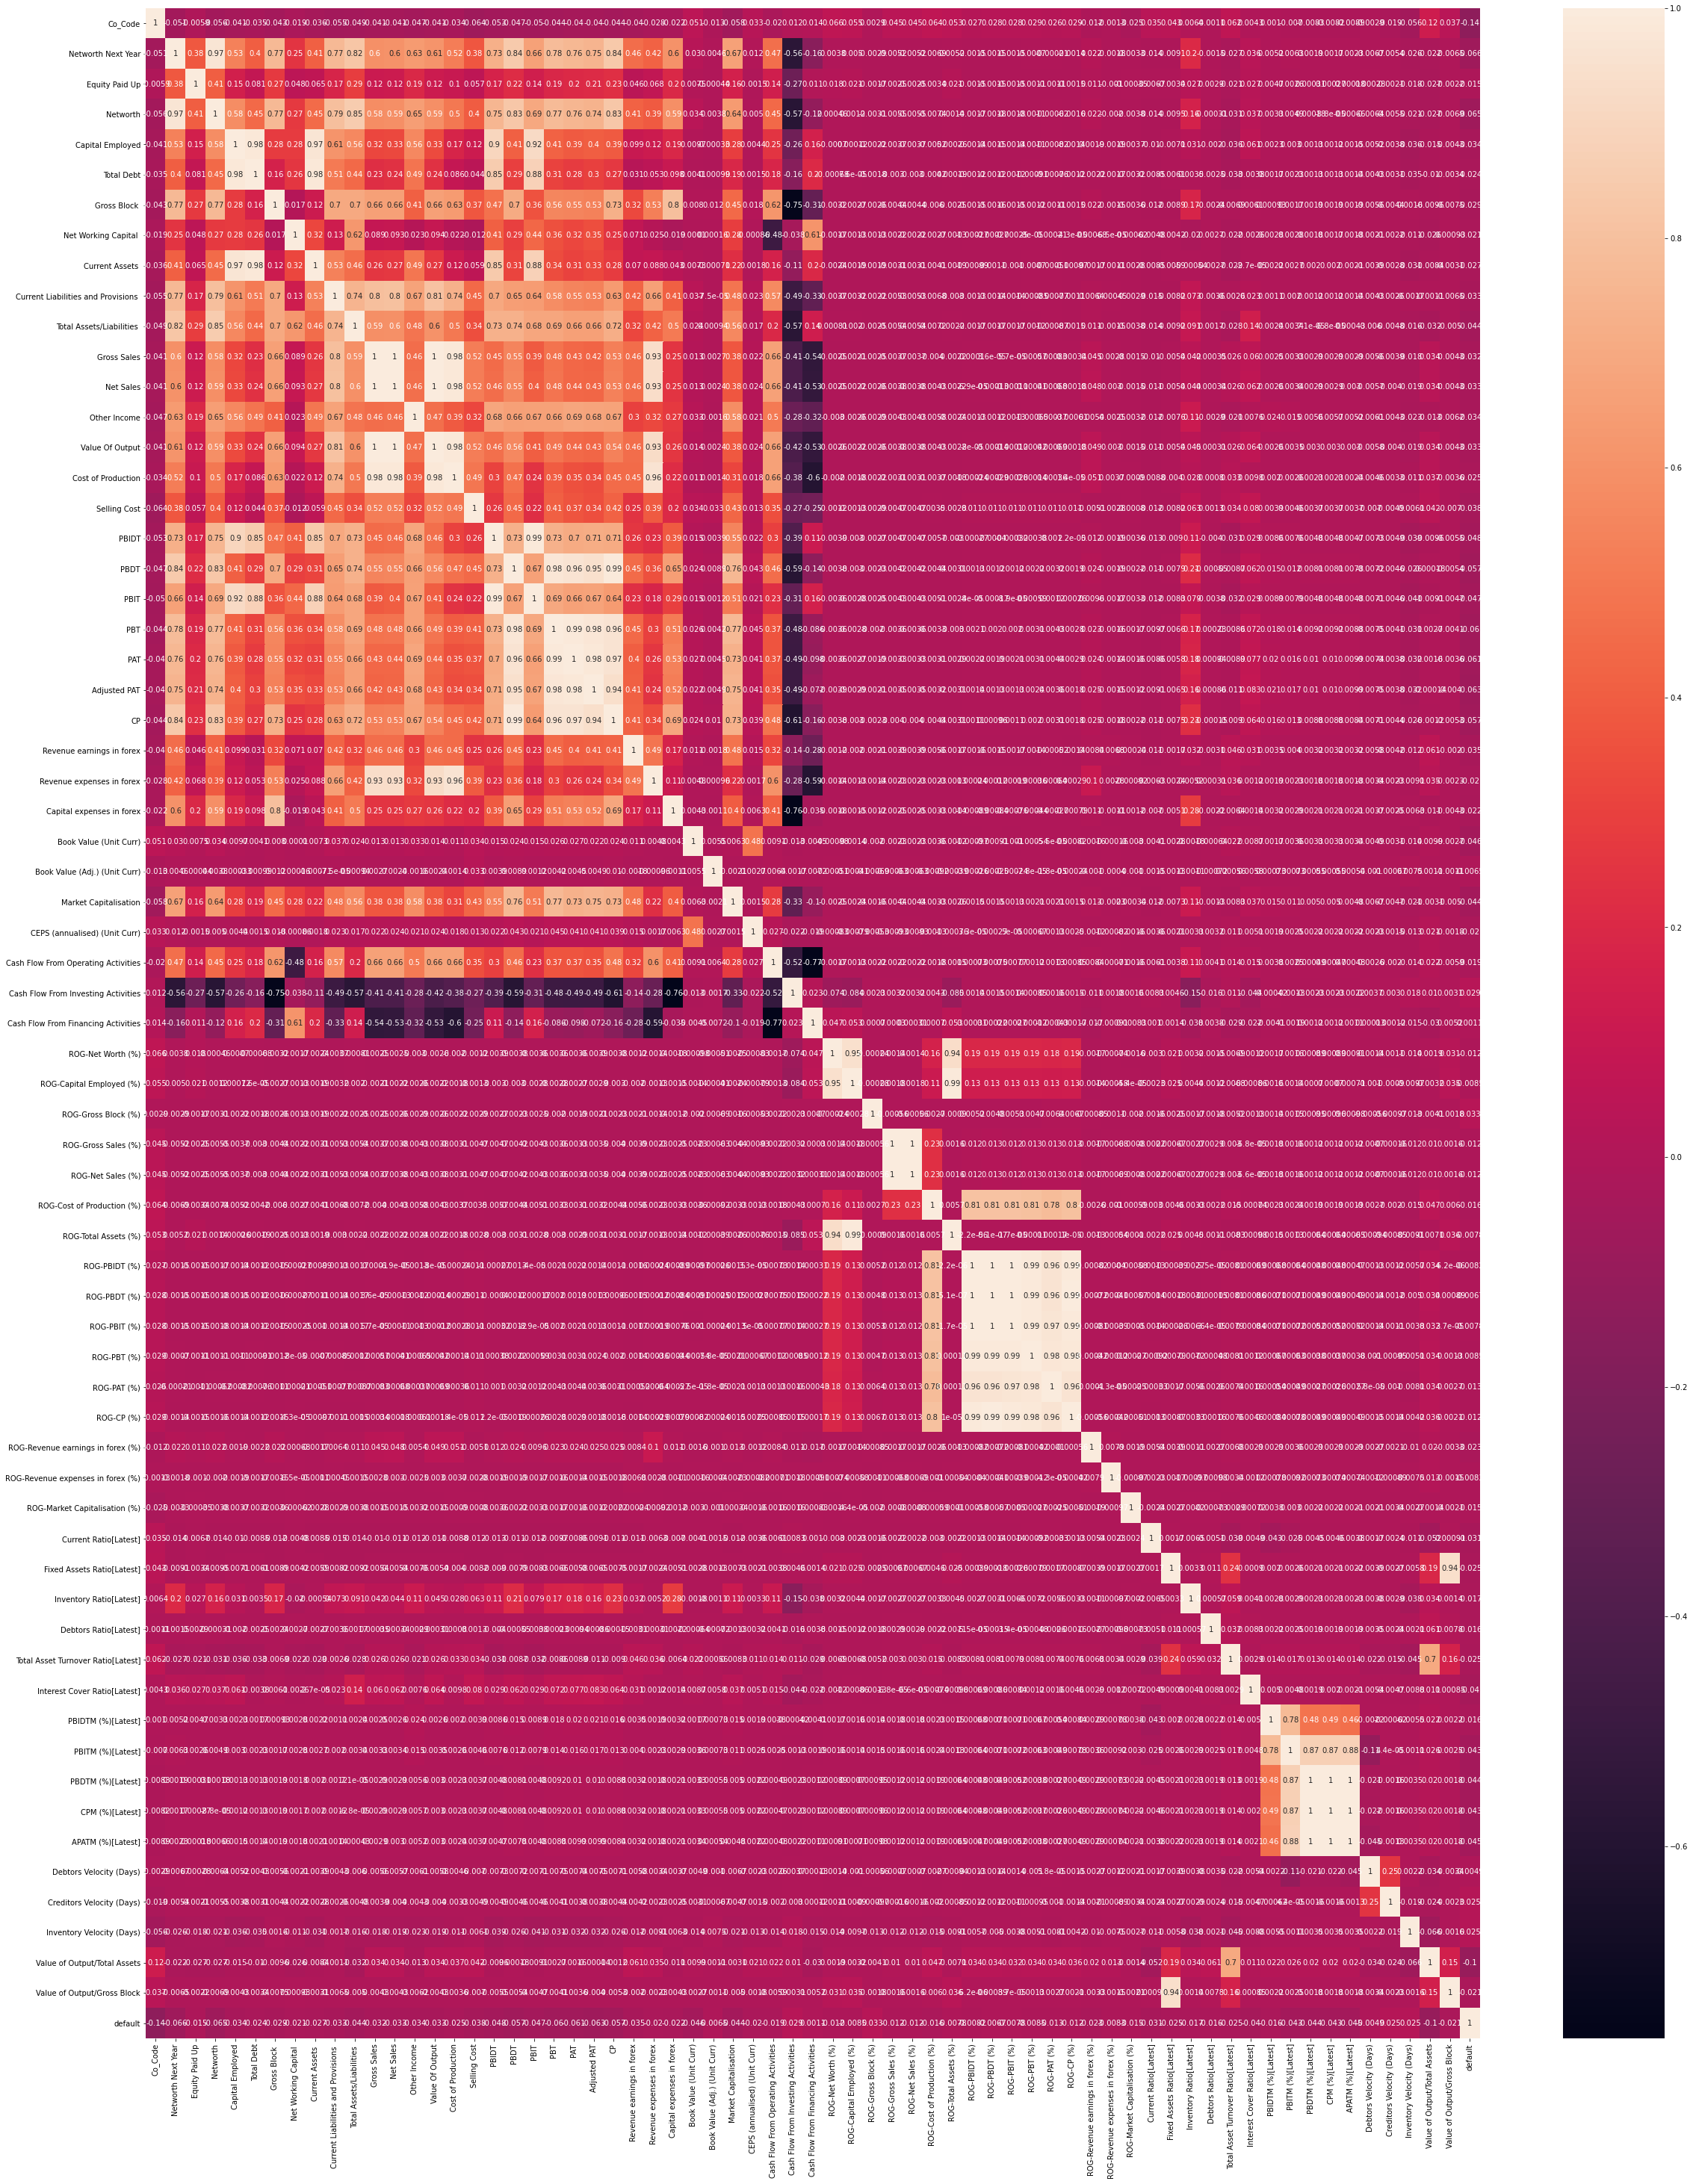

In [32]:
plt.figure(figsize=(40,50))
sns.heatmap(df1.corr(), annot = True)

In [33]:
df1.drop(['Co_Code','Co_Name'], axis =1 , inplace = True)

In [34]:
df1.shape

(3478, 66)

### Perform Train Test Split

In [35]:
X = df1.drop("default", axis=1)

y = df1.pop("default")

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.33, random_state=42)

### Modeling

### Build a Logistic Regression Model on most important variables on Train Dataset

In [37]:
Logit_model = LogisticRegression()
Logit_model.fit(X_train, y_train)

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [38]:
importance = Logit_model.coef_[0]

In [39]:
# Let us explore the coefficients for each of the independent attributes

for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, Logit_model.coef_[0][idx]))

The coefficient for Networth Next Year is -0.01962703518745208
The coefficient for Equity Paid Up is -0.0014174798142717509
The coefficient for Networth is -0.013168015087399577
The coefficient for Capital Employed is -0.007349084573323572
The coefficient for Total Debt is 0.005412902902306848
The coefficient for Gross Block  is 0.0033998586501374243
The coefficient for Net Working Capital  is -0.0006432996178261707
The coefficient for Current Assets  is -0.0011063845539084959
The coefficient for Current Liabilities and Provisions  is 0.0044225543790221275
The coefficient for Total Assets/Liabilities  is 0.002757720678458341
The coefficient for Gross Sales is -0.0010723799577183725
The coefficient for Net Sales is -0.0009460342067581642
The coefficient for Other Income is 0.0003555507780111009
The coefficient for Value Of Output is -0.0014478234886427521
The coefficient for Cost of Production is 0.0009918640389507069
The coefficient for Selling Cost is 3.894578450464372e-05
The coeffic

In [40]:
Logit_model.coef_

array([[-1.96270352e-02, -1.41747981e-03, -1.31680151e-02,
        -7.34908457e-03,  5.41290290e-03,  3.39985865e-03,
        -6.43299618e-04, -1.10638455e-03,  4.42255438e-03,
         2.75772068e-03, -1.07237996e-03, -9.46034207e-04,
         3.55550778e-04, -1.44782349e-03,  9.91864039e-04,
         3.89457845e-05, -9.82128382e-04, -1.63587849e-03,
        -1.15782344e-03, -1.81157355e-03, -1.48197941e-03,
        -2.77544962e-03, -1.30628435e-03, -9.36326974e-04,
         1.22533729e-03, -2.78625133e-05, -1.54858469e-02,
        -1.48786284e-02, -8.14694862e-03, -1.89918739e-03,
        -9.90786968e-04,  7.12927730e-04,  1.91803902e-04,
        -7.64741598e-03, -2.26087728e-03, -2.68699855e-03,
        -3.83732626e-04, -4.74542402e-04,  1.01106722e-04,
         6.30177992e-04,  1.85007907e-04, -1.44686383e-04,
        -5.67163997e-05,  3.40891257e-05, -1.15103895e-05,
         3.47356860e-05, -4.13148639e-03, -2.80901423e-03,
        -5.23938014e-03, -4.73777220e-03, -5.77981472e-0

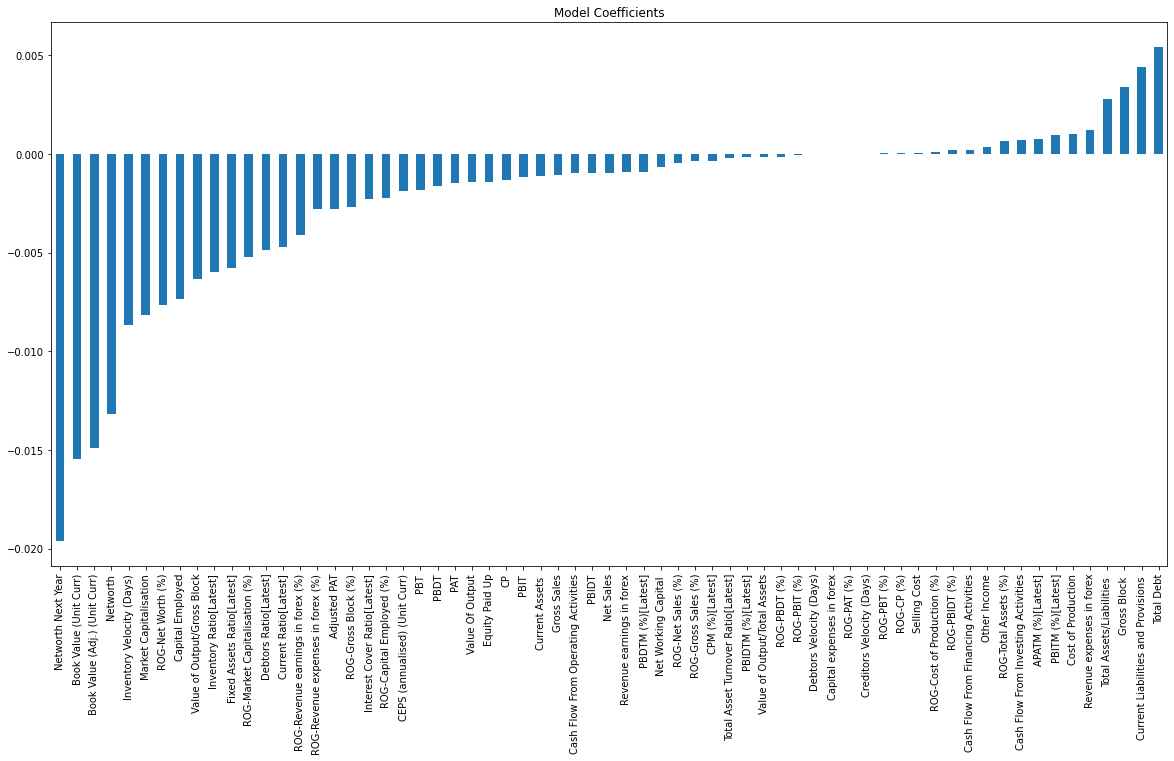

In [41]:
#checking the magnitude of coefficients
from pandas import Series, DataFrame
predictors = X_train.columns

coef = Series(Logit_model.coef_.flatten(), predictors).sort_values()
plt.figure(figsize=(20,10))

coef.plot(kind='bar', title='Model Coefficients')
plt.show()

In [42]:
predictors

Index(['Networth Next Year', 'Equity Paid Up', 'Networth', 'Capital Employed',
       'Total Debt', 'Gross Block ', 'Net Working Capital ', 'Current Assets ',
       'Current Liabilities and Provisions ', 'Total Assets/Liabilities ',
       'Gross Sales', 'Net Sales', 'Other Income', 'Value Of Output',
       'Cost of Production', 'Selling Cost', 'PBIDT', 'PBDT', 'PBIT', 'PBT',
       'PAT', 'Adjusted PAT', 'CP', 'Revenue earnings in forex',
       'Revenue expenses in forex', 'Capital expenses in forex',
       'Book Value (Unit Curr)', 'Book Value (Adj.) (Unit Curr)',
       'Market Capitalisation', 'CEPS (annualised) (Unit Curr)',
       'Cash Flow From Operating Activities',
       'Cash Flow From Investing Activities',
       'Cash Flow From Financing Activities', 'ROG-Net Worth (%)',
       'ROG-Capital Employed (%)', 'ROG-Gross Block (%)',
       'ROG-Gross Sales (%)', 'ROG-Net Sales (%)',
       'ROG-Cost of Production (%)', 'ROG-Total Assets (%)', 'ROG-PBIDT (%)',
       'ROG-

In [43]:
X_train_imp = X_train[['Networth Next Year','Book Value (Unit Curr)','Book Value (Adj.) (Unit Curr)','Networth','Inventory Velocity (Days)','Market Capitalisation','ROG-Net Worth (%)','Capital Employed','Value of Output/Gross Block','Inventory Ratio[Latest]','Fixed Assets Ratio[Latest]',
  'ROG-Market Capitalisation (%)','Debtors Ratio[Latest]','Current Ratio[Latest]','ROG-Revenue earnings in forex (%)','Total Assets/Liabilities ','Gross Block ','Current Liabilities and Provisions ','Total Debt']]

In [44]:
X_test_imp = X_test[['Networth Next Year','Book Value (Unit Curr)','Book Value (Adj.) (Unit Curr)','Networth','Inventory Velocity (Days)','Market Capitalisation','ROG-Net Worth (%)','Capital Employed','Value of Output/Gross Block','Inventory Ratio[Latest]','Fixed Assets Ratio[Latest]',
  'ROG-Market Capitalisation (%)','Debtors Ratio[Latest]','Current Ratio[Latest]','ROG-Revenue earnings in forex (%)','Total Assets/Liabilities ','Gross Block ','Current Liabilities and Provisions ','Total Debt']]

In [45]:
logit_new = LogisticRegression()

In [46]:
logit_new.fit(X_train_imp, y_train)

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### Validate the Model on Test Dataset and state the performance matrices

In [47]:
y_train_predict_logit = logit_new.predict(X_train_imp)
y_test_predict_logit = logit_new.predict(X_test_imp)

In [48]:
print('\n Accuracy score of train data set:\n', accuracy_score(y_train, y_train_predict_logit))
print('\n Accuracy score of test data set:\n', accuracy_score(y_test, y_test_predict_logit)) 
print('\n Confusion Matrix of train data set:\n', confusion_matrix(y_train, y_train_predict_logit)) 
print('\n Confusion Matrix of test data set:\n', confusion_matrix(y_test, y_test_predict_logit)) 
print('\n Classification Report of train data set:\n', classification_report(y_train, y_train_predict_logit))
print('\n Classification Report of test data set:\n', classification_report(y_test, y_test_predict_logit))
print('\n ROC_AUC_Score of train data set:\n', roc_auc_score(y_train, logit_new.predict_proba(X_train_imp)[:,1]))
print('\n ROC_AUC_Score of test data set:\n', roc_auc_score(y_test, logit_new.predict_proba(X_test_imp)[:,1]))


 Accuracy score of train data set:
 0.992274678111588

 Accuracy score of test data set:
 0.9869337979094077

 Confusion Matrix of train data set:
 [[2088    4]
 [  14  224]]

 Confusion Matrix of test data set:
 [[1004    6]
 [   9  129]]

 Classification Report of train data set:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      2092
           1       0.98      0.94      0.96       238

    accuracy                           0.99      2330
   macro avg       0.99      0.97      0.98      2330
weighted avg       0.99      0.99      0.99      2330


 Classification Report of test data set:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1010
           1       0.96      0.93      0.95       138

    accuracy                           0.99      1148
   macro avg       0.97      0.96      0.97      1148
weighted avg       0.99      0.99      0.99      1148


 ROC_AUC_Score of

### Build a Random Forest Model on Train Dataset

In [49]:
rfcl = RandomForestClassifier()

In [50]:
param_grid = {
    'max_depth': [8,12,15],
    'max_features': [10,12,14],
    'min_samples_leaf': [50,80,120],
    'min_samples_split': [150,250,350],
    'n_estimators': [101, 301],
    'random_state': [0]
}

In [51]:
grid_search = GridSearchCV(estimator = rfcl, param_grid = param_grid, cv = 3)

In [ ]:
grid_search.fit(X_train, y_train)

In [ ]:
grid_search.best_params_

In [ ]:
best_grid_rfcl = grid_search.best_estimator_
best_grid_rfcl

In [ ]:
print (pd.DataFrame(best_grid_rfcl.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values('Imp',ascending=False))

### Validate the Random Forest Model on test Dataset and state the performance matrices	

In [ ]:
ytrain_predict_rfcl = best_grid_rfcl.predict(X_train)
ytest_predict_rfcl = best_grid_rfcl.predict(X_test)

ytrain_predict_prob_rfcl = best_grid_rfcl.predict_proba(X_train)
ytest_predict_prob_rfcl = best_grid_rfcl.predict_proba(X_test)

In [ ]:
print('\n Accuracy score of train data set:\n', accuracy_score(y_train, ytrain_predict_rfcl))
print('\n Accuracy score of test data set:\n', accuracy_score(y_test, ytest_predict_rfcl)) 
print('\n Confusion Matrix of train data set:\n', confusion_matrix(y_train, ytrain_predict_rfcl)) 
print('\n Confusion Matrix of test data set:\n', confusion_matrix(y_test, ytest_predict_rfcl)) 
print('\n Classification Report of train data set:\n', classification_report(y_train, ytrain_predict_rfcl))
print('\n Classification Report of test data set:\n', classification_report(y_test, ytest_predict_rfcl))
print('\n ROC_AUC_Score of train data set:\n', roc_auc_score(y_train, best_grid_rfcl.predict_proba(X_train)[:,1]))
print('\n ROC_AUC_Score of test data set:\n', roc_auc_score(y_test, best_grid_rfcl.predict_proba(X_test)[:,1]))

### Build an LDA Model on Train Dataset	

In [53]:
LDA_model = LinearDiscriminantAnalysis()
LDA_model.fit(X_train, y_train)

LinearDiscriminantAnalysis()

### Validate the LDA Model on test Dataset and state the performance matrices	

In [54]:
y_train_predict_LDA = LDA_model.predict(X_train)
y_test_predict_LDA = LDA_model.predict(X_test)

In [55]:
print('\n Accuracy score of train data set:\n', accuracy_score(y_train, y_train_predict_LDA))
print('\n Accuracy score of test data set:\n', accuracy_score(y_test, y_test_predict_LDA)) 
print('\n Confusion Matrix of train data set:\n', confusion_matrix(y_train, y_train_predict_LDA)) 
print('\n Confusion Matrix of test data set:\n', confusion_matrix(y_test, y_test_predict_LDA)) 
print('\n Classification Report of train data set:\n', classification_report(y_train, y_train_predict_LDA))
print('\n Classification Report of test data set:\n', classification_report(y_test, y_test_predict_LDA))
print('\n ROC_AUC_Score of train data set:\n', roc_auc_score(y_train, LDA_model.predict_proba(X_train)[:,1]))
print('\n ROC_AUC_Score of test data set:\n', roc_auc_score(y_test, LDA_model.predict_proba(X_test)[:,1]))


 Accuracy score of train data set:
 0.8982832618025751

 Accuracy score of test data set:
 0.8719512195121951

 Confusion Matrix of train data set:
 [[2080   12]
 [ 225   13]]

 Confusion Matrix of test data set:
 [[995  15]
 [132   6]]

 Classification Report of train data set:
               precision    recall  f1-score   support

           0       0.90      0.99      0.95      2092
           1       0.52      0.05      0.10       238

    accuracy                           0.90      2330
   macro avg       0.71      0.52      0.52      2330
weighted avg       0.86      0.90      0.86      2330


 Classification Report of test data set:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93      1010
           1       0.29      0.04      0.08       138

    accuracy                           0.87      1148
   macro avg       0.58      0.51      0.50      1148
weighted avg       0.81      0.87      0.83      1148


 ROC_AUC_Score of tr

### Compare the performances of all the three models (include ROC Curve)

### Logistic Regression

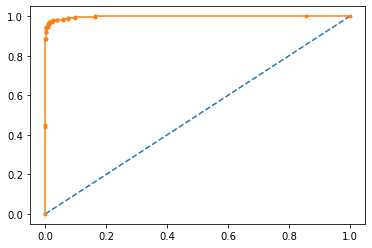

In [51]:
fpr_log_reg_train, tpr_log_reg_train, tresholds_log_reg_train = roc_curve(y_train, logit_new.predict_proba(X_train_imp)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_log_reg_train, tpr_log_reg_train, marker='.')

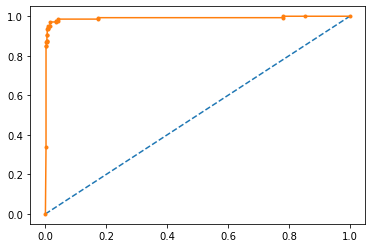

In [52]:
fpr_log_reg_test, tpr_log_reg_test, tresholds_log_reg_test = roc_curve(y_test, logit_new.predict_proba(X_test_imp)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_log_reg_test, tpr_log_reg_test, marker='.')

### Random Forest Classifier

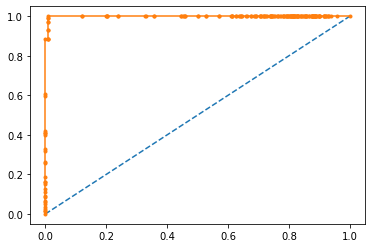

In [55]:
fpr_RFCL_train, tpr_RFCL_train, tresholds_RFCL_train = roc_curve(y_train, best_grid_rfcl.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_RFCL_train, tpr_RFCL_train, marker='.')

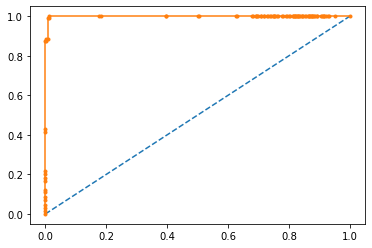

In [56]:
fpr_RFCL_test, tpr_RFCL_test, tresholds_RFCL_test = roc_curve(y_test, best_grid_rfcl.predict_proba(X_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_RFCL_test, tpr_RFCL_test, marker='.')

### LDA

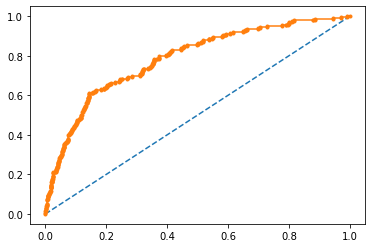

In [56]:
fpr_LDA_train, tpr_LDA_train, tresholds_LDA_train = roc_curve(y_train, LDA_model.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_LDA_train, tpr_LDA_train, marker='.')

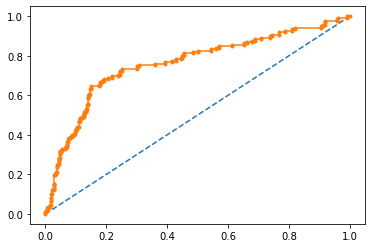

In [57]:
fpr_LDA_test, tpr_LDA_test, tresholds_LDA_test = roc_curve(y_test, LDA_model.predict_proba(X_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_LDA_test, tpr_LDA_test, marker='.')

### Recommendations:

### 1) In terms of accuracy, it is very much evident that Logistic Regression and Random Forest Classifier are performing better compared to LDA.
### 2) LDA model is not performing good as it is not able to capture the defaulters properly due its low precision and re-call.
### 3) we can see that Precision, Recall, Accuracy are high for the models build on Logistic Regression and Random Forest Classifier by looking at the performance metrics. 
### 4) The attributes such as Networth Next Year, Book Value, Net Worth, Inventory Velocity, Market Cap and Total Debts contribute more for the classification of the defaulters. Hence the company is required to focus on these variables and make sure there is minimal error, missing values in capturing this data.
### 5) We can conclude that the Logistic Regression model has the best metrics when it comes to Precision and Recall and accuracy.


## Part 2- Market Risk

### The dataset contains 6 years of information(weekly stock information) on the stock prices of 10 different Indian Stocks. Calculate the mean and standard deviation on the stock returns and share insights.

In [58]:
df2 = pd.read_csv("Market+Risk+Dataset.csv")

### Basic EDA

In [59]:
df2.head()

,Date,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
0,31-03-2014,264,69,455,263,68,5543,555,298,83,278
1,07-04-2014,257,68,458,276,70,5728,610,279,84,303
2,14-04-2014,254,68,454,270,68,5649,607,279,83,280
3,21-04-2014,253,68,488,283,68,5692,604,274,83,282
4,28-04-2014,256,65,482,282,63,5582,611,238,79,243


In [60]:
df2.shape

(314, 11)

In [61]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Date                 314 non-null    object
 1   Infosys              314 non-null    int64 
 2   Indian Hotel         314 non-null    int64 
 3   Mahindra & Mahindra  314 non-null    int64 
 4   Axis Bank            314 non-null    int64 
 5   SAIL                 314 non-null    int64 
 6   Shree Cement         314 non-null    int64 
 7   Sun Pharma           314 non-null    int64 
 8   Jindal Steel         314 non-null    int64 
 9   Idea Vodafone        314 non-null    int64 
 10  Jet Airways          314 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 27.1+ KB


In [62]:
df2.describe()

,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
count,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000
mean,511.340764,114.560510,636.678344,540.742038,59.095541,14806.410828,633.468153,147.627389,53.713376,372.659236
std,135.952051,22.509732,102.879975,115.835569,15.810493,4288.275085,171.855893,65.879195,31.248985,202.262668
min,234.000000,64.000000,284.000000,263.000000,21.000000,5543.000000,338.000000,53.000000,3.000000,14.000000
25%,424.000000,96.000000,572.000000,470.500000,47.000000,10952.250000,478.500000,88.250000,25.250000,243.250000
50%,466.500000,115.000000,625.000000,528.000000,57.000000,16018.500000,614.000000,142.500000,53.000000,376.000000
75%,630.750000,134.000000,678.000000,605.250000,71.750000,17773.250000,785.000000,182.750000,82.000000,534.000000
max,810.000000,157.000000,956.000000,808.000000,104.000000,24806.000000,1089.000000,338.000000,117.000000,871.000000


### Draw Stock Price Chart for any 2 variables	

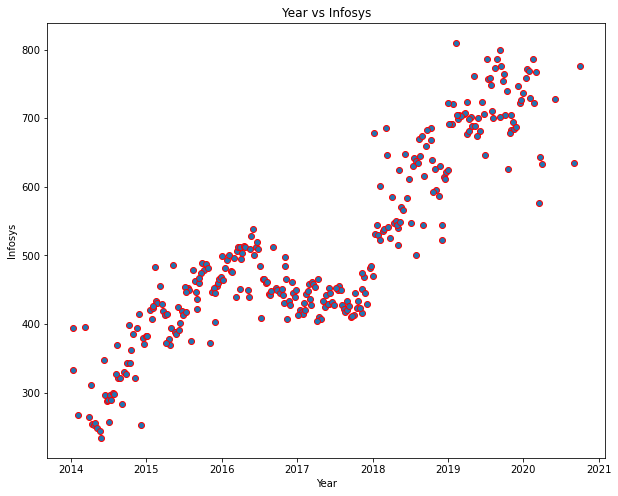

In [63]:
plt.figure(figsize = (10, 8))
df2['dates'] = [pd.to_datetime(d) for d in df2['Date']]
plt.scatter(df2['dates'], df2['Infosys'], edgecolors='r')
plt.xlabel('Year')
plt.ylabel('Infosys')
plt.title('Year vs Infosys')

plt.show()

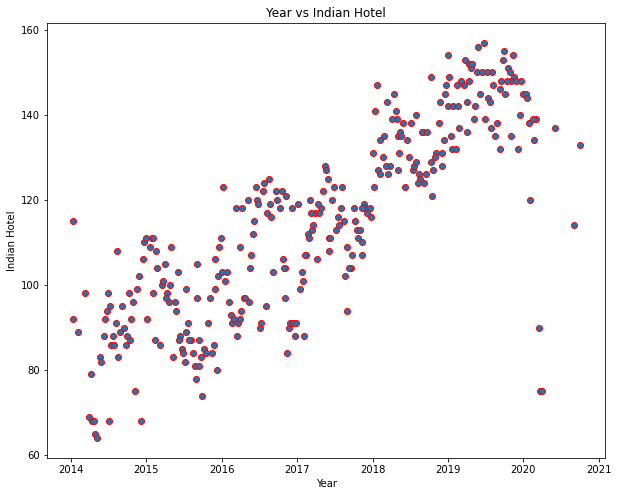

In [64]:
plt.figure(figsize = (10, 8))
df2['dates'] = [pd.to_datetime(d) for d in df2['Date']]
plt.scatter(df2['dates'], df2['Indian Hotel'], edgecolors='r')
plt.xlabel('Year')
plt.ylabel('Indian Hotel')
plt.title('Year vs Indian Hotel')

plt.show()

### Calculate Returns

In [65]:
stock_returns = np.log(df2.drop(['Date','dates'],axis=1)).diff(axis = 0, periods = 1) 

In [66]:
stock_returns.shape

(314, 10)

In [67]:
    stock_returns.head()

,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.026873,-0.014599,0.006572,0.048247,0.028988,0.032831,0.094491,-0.065882,0.011976,0.086112
2,-0.011742,0.000000,-0.008772,-0.021979,-0.028988,-0.013888,-0.004930,0.000000,-0.011976,-0.078943
3,-0.003945,0.000000,0.072218,0.047025,0.000000,0.007583,-0.004955,-0.018084,0.000000,0.007117
4,0.011788,-0.045120,-0.012371,-0.003540,-0.076373,-0.019515,0.011523,-0.140857,-0.049393,-0.148846


### Calculate Stock Means

In [68]:
stock_means = stock_returns.mean(axis = 0)
stock_means

Infosys                0.002794
Indian Hotel           0.000266
Mahindra & Mahindra   -0.001506
Axis Bank              0.001167
SAIL                  -0.003463
Shree Cement           0.003681
Sun Pharma            -0.001455
Jindal Steel          -0.004123
Idea Vodafone         -0.010608
Jet Airways           -0.009548
dtype: float64

### Calculate Standard Deviation

In [69]:
stock_sd = stock_returns.std(axis = 0)
stock_sd

Infosys                0.035070
Indian Hotel           0.047131
Mahindra & Mahindra    0.040169
Axis Bank              0.045828
SAIL                   0.062188
Shree Cement           0.039917
Sun Pharma             0.045033
Jindal Steel           0.075108
Idea Vodafone          0.104315
Jet Airways            0.097972
dtype: float64

### Draw a plot of Stock Means vs Standard Deviation

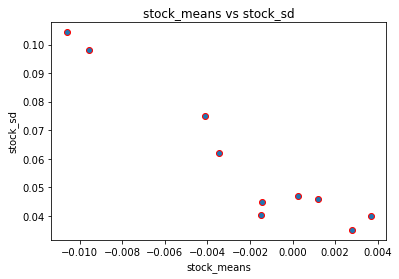

In [70]:
plt.scatter(stock_means, stock_sd, edgecolors='r')
plt.xlabel('stock_means')
plt.ylabel('stock_sd')
plt.title('stock_means vs stock_sd')
plt.show()

#### Stock with a lower mean & higher standard deviation do not play a role in a portfolio that has competing stock with more returns & less risk. 
#### Thus for the data we have One with highest return and lowest risk.

#### Therefore :-
#### from pure Returns perspective, Shree Cement looks good in this dataset followed by Infosys and Axis Bank 
#### from pure Risk perspective Infosys looks good (as measured by standard deviation) followed by Shree Cement and Mahindra & Mahindra.

#### Overall, Shree Cement and Infosys looks good in this dataset.